In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import copy
import random
import numpy as np
import torch.optim as optim
from tqdm.notebook import tqdm, trange
from torchvision import datasets
import time
from torch_lr_finder import LRFinder
import gc
from GPUtil import showUtilization as gpu_usage
from GPUtil import getGPUs
from torchvision.transforms import v2
import os
import shutil

C:\Users\agomez\miniconda3\envs\Chimera\Lib\site-packages\torch_lr_finder\lr_finder.py:5: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
from IPython.core.display import HTML

# See https://github.com/bstriner/keras-tqdm/issues/21#issuecomment-443019223
display(HTML("""
    <style>
        .jp-OutputArea-child:has(.jp-OutputArea-prompt:empty) {
              padding: 0 !important;
        }
    </style>
"""))


## Reproducibility

Here, we set the seed manually to be able to replicate the experiments

In [3]:
seed_value=42
np.random.seed(seed_value) # cpu vars
random.seed(seed_value) # Python
os.environ['PYTHONHASHSEED'] = str(seed_value)
os.environ['CUBLAS_WORKSPACE_CONFIG']=":4096:8"
torch.manual_seed(seed_value) # cpu vars
torch.use_deterministic_algorithms(True,warn_only=True)
torch.cuda.manual_seed_all(seed_value) # gpu vars
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
def trainloop(model, train_loader, val_loader, epochs = 10, lr = 1e-3, patience = 0, max_gpu_percentage = 0, test_batches = 2):
    model.to(model.device)
    optimizer = optim.AdamW(model.parameters(), lr)
    
    model.train()
    training_loss = []
    validation_loss = []
    overfit = 0
    best_loss = np.inf
    with tqdm(total = epochs, leave = False, desc='Training model') as pbar1:
        for epoch in range(epochs):
            running_loss = 0.0
            with tqdm(total=len(train_loader), leave = False, desc='Epoch progress') as pbar2:
                for inputs, labels in train_loader:
                    inputs, labels = inputs.to(model.device), labels.to(model.device)
                    # zero the parameter gradients
                    optimizer.zero_grad()
                    # forward + backward + optimize
                    outputs = model(inputs).squeeze()
                    loss = criterion(outputs, labels)
                    #print(loss)
                    loss.backward()
                    optimizer.step()

                    if max_gpu_percentage: # If there is a cap to the GPU memory it can occupy, 
                        gpus = getGPUs()
                        for gpu in gpus:
                            gpu_overuse = np.sum([(gpu.memoryUsed/gpu.memoryTotal) > max_gpu_percentage for gpu in gpus])
                            if gpu_overuse:
                                pbar1.update(np.inf)
                                pbar2.update(np.inf)
                                raise Exception("This model will use too much GPU memory.")
                        test_batches -= 1
                        if test_batches == 0:
                            pbar2.update(1)
                            break
                    running_loss += loss.item()
                    pbar2.update(1)
                pbar2.update(np.inf)
            training_loss.append(running_loss/len(train_loader))

            if val_loader:
                model.eval()
                running_loss = 0.
                with tqdm(total=len(val_loader), leave = False, desc='Calculating validation loss') as pbar3:
                    with torch.no_grad():
                        for inputs, labels in val_loader:
                            inputs, labels = inputs.to(model.device), labels.to(model.device)
                            outputs = model.forward(inputs)
                            loss = criterion(outputs, labels)
                            running_loss += loss.detach().cpu().numpy()
                            pbar3.update(1)
                        pbar3.update(np.inf)
                validation_loss.append(running_loss/len(val_loader))
        
                if patience:
                    if validation_loss[-1] < best_loss:
                        best_loss = validation_loss[-1]
                        overfit = 0
                        torch.save(model.state_dict(), "training_model.pt")
                    else:
                        overfit += 1

                    if overfit >= patience/2:
                        optimizer = optim.AdamW(model.parameters(), optimizer.defaults["lr"]/2)
                    
                    if overfit >= patience: # If the nectar decreases for an entire cycle we assume overfitting
                        pbar1.update(epochs)
                        break
            pbar1.update(1)
        pbar1.update(np.inf)
    model.to("cpu")
    if patience:
        model.load_state_dict(torch.load("training_model.pt"))
    
    del optimizer, loss, inputs, labels, outputs
    free_gpu_cache()

    return model

def accmetric(model, dataloader):
    model.to(model.device)
    model.eval()
    
    accuracy = 0
    # Turn off gradients for validation, saves memory and computations
    with tqdm(total=len(dataloader), leave = False, desc='Calculating accuracy') as pbar:
        with torch.no_grad():
            for inputs, labels in dataloader:
                inputs, labels = inputs.to(model.device), labels.to(model.device)
                logprobs = model.forward(inputs)
                top_p, top_class = logprobs.topk(1, dim=1)
                equals = (top_class == labels.view(inputs.shape[0], 1))
                accuracy += torch.mean(equals.type(torch.FloatTensor))
                pbar.update(1)
    model.to("cpu")
    free_gpu_cache()
    return accuracy.detach().numpy()/len(dataloader)

def free_gpu_cache(show_usage = False):
# This function is used to clear the GPU cache and avoid memory problems when dealing with large populations and big models
    if show_usage:
        print("Initial GPU Usage")
        gpu_usage()
    gc.collect()
    torch.cuda.ipc_collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    if show_usage:
        print("GPU Usage after emptying the cache")
        gpu_usage()

In [5]:
class conv_block(nn.Module):
    def __init__(self, in_c, out_c, kernel_size = 3):
        self.kernel_size = kernel_size
        padding = int((kernel_size + 1)/2)
        self.padding = padding
        super().__init__()
        self.conv = nn.Conv2d(in_c, out_c, kernel_size=kernel_size, padding=padding)
        self.bn = nn.BatchNorm2d(out_c)
        self.relu = nn.ReLU()
        
    def forward(self, inputs):
        x = self.conv(inputs)
        x = self.bn(x)
        x = self.relu(x)
        return x  

class block(nn.Module):
    def __init__(self, in_c, out_c, resizing_type = None, from_block_channels = 0, kernel_size = 3):
        super().__init__()
        self.resizing_type = resizing_type
        self.kernel_size = kernel_size
        self.in_c = in_c
        self.out_c = out_c
        self.from_block_channels = from_block_channels
        
        if resizing_type == "D":
            self.resizing = nn.MaxPool2d((2, 2))
        elif resizing_type == "U":
            self.resizing = nn.ConvTranspose2d(in_c, in_c, kernel_size=2, stride=2, padding=0)
        else:
            self.resizing = nn.Identity()
        
        self.conv = conv_block(from_block_channels+in_c, out_c, kernel_size = kernel_size)
        
    def forward(self, inputs, skip):
        x = self.resizing(inputs)
        
        for extra_input in skip:
            x = torch.cat([x, nn.functional.interpolate(extra_input, size = [x.shape[2], x.shape[3]])], axis=1)
        x = self.conv(x)
        return x

class optimized_network(nn.Module):
    """
    A Convolutional Neural Network generated randomly.
    """
    def __init__(self, dataloader, n_blocks = 1, task = "infere", out_size = None, logmin_c = 5, logmax_c = 8, max_k = 9, complex_classifier = False, max_gpu_percentage = 0.90, verbose = False):
        super().__init__()
        
        if hasattr(n_blocks, '__iter__'):
            if len(n_blocks) not in [1,2]:
                raise Exception("Invalid range for model initial layers.")
        elif n_blocks == int(n_blocks):
            n_blocks = [int(n_blocks), int(n_blocks)]
        else:
            raise Exception("Model initial layers needs to be either a scalar or a scalar range.")

        self.dataloader = dataloader
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.logmin_c = logmin_c
        self.logmax_c = logmax_c
        self.max_k = max_k
        self.complex_classifier = complex_classifier
        self.max_gpu_percentage = max_gpu_percentage
        
        batch = next(iter(dataloader))
        self.in_size = batch[0].shape
        self.label_size = batch[1].shape
        
        targets = dataloader.dataset.targets
        
        if task not in ["image_to_image", "image_to_mask", "object_detection", "regression", "classification", "infere"]:
            print("Unknown task. Infering task from dataset.")
            task = "infere"
        if task == "infere":
            if batch[0].shape[-2:] == batch[1].shape[-2:]:
                if batch[1].is_floating_point():
                    self.task = "image_to_image"
                else:
                    if batch[1].shape[-3] == 1:
                        self.task = "image_to_mask"
                    else:
                        self.task = "object_detection"
            else:
                if batch[1].is_floating_point():
                    self.task = "regression"
                else:
                    self.task = "classification"
        else:
            self.task = task

        if out_size:
            self.out_size = out_size
        else:
            if self.task == "classification" or self.task == "object_detection":
                self.out_size = max(targets) + 1
            else:
                self.out_size = batch[1].shape[1:]
        
        invalid = self.initialize_network(n_blocks = random.randint(n_blocks[0], n_blocks[1]), verbose = verbose)
        while invalid:
            del self.features, self.fc
            free_gpu_cache()
            if verbose:
                print("Invalid network. Retrying.")
            invalid = self.initialize_network(n_blocks = random.randint(n_blocks[0], n_blocks[1]), verbose = verbose)
                    
    def initialize_network(self, n_blocks, verbose):
        try:
            self.connections = [[]] * n_blocks
            self.features = nn.Sequential()
            self.genome = []
            for l in range(n_blocks):
                if l == 0:
                    in_c = self.in_size[1]
                else:
                    in_c = out_c
                
                if l == n_blocks-1 and self.task != "classification":
                    out_c = self.out_size
                else:
                    out_c = 2**random.randint(self.logmin_c, self.logmax_c)
                
                if n_blocks - l <= 2:
                    to_blocks = [] # One Block cannot connect to itself, and the connection to the next block is implied
                else:
                    to_blocks = random.choice([random.sample(list(range(l+2, n_blocks)), k = random.randint(1, n_blocks-l-2)), []]) # It can, however, skip-connect to any number of blocks from two away to the last
                
                resizing_type = random.choice(["U", "D", ""])
                self.connections[l] = to_blocks
    
                from_blocks = [i for i, x in enumerate(self.connections) if l in x]
                from_block_channels = 0
                for from_block in from_blocks:
                    from_block_channels += self.features[from_block].out_c
                
                kernel_size = random.randint(0,int((self.max_k-1)/2))*2+1
                self.features = nn.Sequential(*list(self.features.children()), block(in_c = in_c, out_c = out_c, resizing_type = resizing_type, from_block_channels = from_block_channels, kernel_size = kernel_size))

            for i in range(len(self.connections)):
                self.connections[i].sort() # We order the connections so that they are tidy
            
            self.build_fc()

            # We try to train for an epoch to see if we have any errors, for instance if the model is too big for the GPU
            self = trainloop(self, train_loader = self.dataloader, val_loader = None, epochs = 1, lr = 1e-10, max_gpu_percentage = self.max_gpu_percentage, test_batches = 4)
            return False
        except Exception as e:
            if verbose:
                print(e)
            return True

    def build_fc(self):
        self.fc = nn.Sequential(nn.Identity())
        if self.task == "classification":
            feat_size = np.prod([*self.to(self.device).forward(torch.zeros(self.in_size, device = self.device)).shape[1:]])
            free_gpu_cache()
            if self.complex_classifier:
                self.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(feat_size, self.out_size*4), nn.ReLU(), nn.Dropout(0.5), nn.Linear(self.out_size*4, self.out_size*2), nn.ReLU(), nn.Dropout(0.5), nn.Linear(self.out_size*2, self.out_size), nn.LogSoftmax(dim=0))
            else:
                self.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(feat_size, self.out_size), nn.LogSoftmax(dim=0))
                
    def mutate(self, mut_amount = 1, probs = {"add_b" : 0.25, "delete_b" : 0.25, "modify_b" : 0.2, "add_c" : 0.15, "delete_c" : 0.05, "change_fc" : 0.05, "reset_w" : 0.05}, verbose = False):
        operations = list(probs.keys())
        
        backup_features = copy.deepcopy(self.features)
        backup_fc = copy.deepcopy(self.fc)
        backup_connections = copy.deepcopy(self.connections)
        
        valid_model = False
        while not valid_model:
            try:
                mutations = random.choices(operations, weights = [probs[operation] for operation in operations], k = mut_amount)
                for mut in mutations:
                    match mut:
                        case "add_b":
                            self.add_block(verbose)
                        case "delete_b":
                            if len(self.features) > 1: # If we can't delete any block, we add one instead
                                self.delete_block(verbose)
                            else:
                                self.add_block(verbose)
                        case "modify_b":
                            self.modify_block(verbose)
                        case "add_c":
                            if not self.add_connection(verbose): # If we can't add a connection, we delete one instead
                                self.delete_connection(verbose)
                        case "delete_c":
                            if not self.delete_connection(verbose): # If we can't delete a connection, we add one instead
                                self.add_connection(verbose)
                        case "change_fc":
                            self.change_fc(verbose)
                        case "reset_w":
                            self.reset_weights(verbose)
    
                for i in range(len(self.connections)):
                    self.connections[i].sort() # We order the connections so that they are tidy
                
                self.build_fc()
        
                # We try to train for an epoch to see if we have any errors, for instance if the model is too big for the GPU
                self = trainloop(self, train_loader = self.dataloader, val_loader = None, epochs = 1, lr = 1e-10, max_gpu_percentage = self.max_gpu_percentage)
                valid_model = True
                
            except Exception as e:
                if verbose:
                    print(e)
                self.features = copy.deepcopy(backup_features)
                self.fc = copy.deepcopy(backup_fc)
                self.connections = copy.deepcopy(backup_connections)
            
        del backup_features, backup_fc, backup_connections

    def add_block(self, verbose = False):
        # We chose a random block to add another one after
        index = random.randint(0, len(self.features)-1)
        if verbose:
            print("Added block between blocks", index, "and " + str(index+1)+".")

        self.connections = self.connections[:index+1] + [[]] + self.connections[index+1:] # We add space for the new block to make connections
        self.connections = [[b[c]*(b[c] <= index) + (b[c]+1)*((b[c]) > index) for c in range(len(b))] for b in self.connections] # And we adjust the indexes of all connections

        # We chose the hyperparameters for the new block
        if self.task not in ["classification", "regression"]:
            resizing_type = "" # If we need the output size to remain constant we do not add a resizing
        else:
            resizing_type = random.choice(["U", "D", ""])
        kernel_size = random.randint(0,int((self.max_k-1)/2))*2+1
        
        features = nn.Sequential(*list(self.features.children())[:index+1], # We keep the previous blocks, add a block with in and out channels equal to the output channels of the previous block
                                  block(in_c = self.features[index].out_c, out_c = self.features[index].out_c, resizing_type = resizing_type, from_block_channels = 0, kernel_size = kernel_size),
                                 *list(self.features.children())[index+1:]) # And then add the remaining blocks
        
        self.features = features

    def delete_block(self, verbose = False):
        # We chose a random block to delete
        index = random.randint(0, len(self.features)-1)
        if verbose:
            print("Block", index, "deleted.")

        self.connections.pop(index) # We delete the skip connections of the deleted block
        self.connections = [[b[c]*(b[c] < index) + (b[c]-1)*((b[c]) > index) for c in range(len(b)) if index != b[c]] for b in self.connections] # We adjust the indexes of all connections
        self.connections = [[b[c] for c in range(len(b)) if b[c]-1 != i] for i, b in enumerate(self.connections)] # And we remove the skip connections btween contiguous blocks

        if index == len(self.features)-1: # If it's the last block, we just remove it
            self.features = nn.Sequential(*list(self.features.children())[:index])
        else: # If not, we have to modify the input channels of the subsequent block and add the rest of the blocks onwards, taking the new skipping connections into consideration
            from_blocks = [i for i, x in enumerate(self.connections) if index in x]
            from_block_channels = 0
            for from_block in from_blocks:
                from_block_channels += self.features[from_block].out_c
                    
            features = nn.Sequential(*list(self.features.children())[:index],
                                          block(in_c = self.features[index].in_c, out_c = self.features[index+1].out_c, resizing_type = self.features[index+1].resizing_type, from_block_channels = from_block_channels, kernel_size = self.features[index+1].kernel_size))
            
            for l, blk in enumerate(list(self.features.children())[index+2:]):
                from_blocks = [i for i, x in enumerate(self.connections) if index+1+l in x]
                from_block_channels = 0
                for from_block in from_blocks:
                    from_block_channels += features[from_block].out_c

                features = nn.Sequential(*list(features.children()), block(in_c = blk.in_c, out_c = blk.out_c, resizing_type = blk.resizing_type, from_block_channels = from_block_channels, kernel_size = blk.kernel_size))

            self.features = features

    def modify_block(self, verbose = False):
        # We chose a random block to modify
        index = random.randint(0, len(self.features)-1)
        if verbose:
            print("Block", index, "modified.")

        out_c = 2**random.randint(self.logmin_c, self.logmax_c)
        resizing_type = random.choice(["U", "D", ""])
        kernel_size = random.randint(0,int((self.max_k-1)/2))*2+1
        features = nn.Sequential(*list(self.features.children())[:index], # We keep the previous blocks and add a modified block
                                  block(in_c = self.features[index].in_c, out_c = out_c, resizing_type = resizing_type, from_block_channels = self.features[index].from_block_channels, kernel_size = kernel_size))
        
        for l, blk in enumerate(list(self.features.children())[index+1:]): # We add the next blocks, modifying the connections accordingly and adapting the input channels on the first one
            from_blocks = [i for i, x in enumerate(self.connections) if index+1+l in x]
            from_block_channels = 0
            for from_block in from_blocks:
                from_block_channels += features[from_block].out_c

            features = nn.Sequential(*list(features.children()),
                                     block(in_c = out_c, out_c = blk.out_c, resizing_type = blk.resizing_type, from_block_channels = from_block_channels, kernel_size = blk.kernel_size))

            out_c = blk.out_c
        
        self.features = features
        
    def add_connection(self, verbose = False):
        try:
            possible_indexes = [i for i, x in enumerate(self.connections) if i+len(x)+2 < len(self.connections)] # We check where we could add a connection
            index = random.sample(possible_indexes, 1)[0] # We select one of those blocks (if there aren't any this will throw an error and abort)
            new_connection = random.sample([i for i in range(index+2, len(self.connections)) if i not in self.connections[index]], 1)[0] # We select where to add a new connection
            self.connections[index] += [new_connection] # We add the new connection
            from_blocks = [i for i, x in enumerate(self.connections) if new_connection in x]
            from_block_channels = 0
            for from_block in from_blocks:
                from_block_channels += self.features[from_block].out_c # We check the new input size of the connected block and modify it accordingly
            self.features[new_connection] = block(in_c = self.features[new_connection].in_c, out_c = self.features[new_connection].out_c, resizing_type = self.features[new_connection].resizing_type, from_block_channels = from_block_channels, kernel_size = self.features[new_connection].kernel_size)
            if verbose:
                print("Skip connection added from block", index, "to block " + str(new_connection)+".")
            return True
        except:
            return False

    def delete_connection(self, verbose = False):
        try:
            blocks_with_connections = [i for i, x in enumerate(self.connections) if x] # We check which blocks do have connections
            index = random.sample(blocks_with_connections, 1)[0] # We chose a block to remove a connection from (if there's none this will throw an error and abort)
            delete_connection = random.sample(self.connections[index], 1)[0] # Then, we select one connection from that block
            self.connections[index] = [c for c in self.connections[index] if c != delete_connection] # We remove the selected connection
            from_blocks = [i for i, x in enumerate(self.connections) if delete_connection in x]
            from_block_channels = 0
            for from_block in from_blocks:
                from_block_channels += self.features[from_block].out_c # We check the new input size of the connected block and modify it accordingly
            self.features[delete_connection] = block(in_c = self.features[delete_connection].in_c, out_c = self.features[delete_connection].out_c, resizing_type = self.features[delete_connection].resizing_type, from_block_channels = from_block_channels, kernel_size = self.features[delete_connection].kernel_size)
            if verbose:
                print("Skip connection removed from block", index, "to block " + str(delete_connection)+".")
            return True
        except Exception as e:
            return False

    def change_fc(self, verbose = False):
        self.complex_classifier = not self.complex_classifier
        if verbose:
            if self.complex_classifier:
                print("Classifier changed from simple to complex.")
            else:
                print("Classifier changed from complex to simple.")

    def reset_weights(self, verbose = False):
        for i, _ in enumerate(self.features):
            nn.init.xavier_uniform_(self.features[i].conv.conv.weight.data, gain=nn.init.calculate_gain('relu'))
            if type(self.features[i].resizing_type) == "U":
                nn.init.xavier_uniform_(self.features[i].resizing.weight.data, gain=nn.init.calculate_gain('relu'))
        if verbose:
            print("Model weights reset.")

    def forward(self, inputs):
        skip = [[]]*len(self.features)
        x = inputs
        for i, l in enumerate(self.features):
            x = l(x, skip[i])
            for to_block in self.connections[i]:
                skip[to_block] = skip[to_block]+[x]
        if (self.task == "classification" or self.task == "regression"):
            x = torch.flatten(x, start_dim=1)
            for l in self.fc:
                x = l(x)
        else:
            x = nn.functional.interpolate(x, size = [inputs.shape[2], inputs.shape[3]])
        del skip
        return x

def crossover(model1, model2, cross_at = "half"):
    code1 = codify(model1) # We codify both models
    code2 = codify(model2)
    
    path = calculate_shortest_path(code1, code2, min(model1.logmin_c, model2.logmin_c), max(model1.logmax_c, model2.logmax_c), max(model1.max_k, model2.max_k), show_paths = False) # And calculate the shortest path to go from one to the other

    if cross_at == "half": # Crossover at half the required operations
        cross_at = len(path[2])//2 +1
    elif cross_at == "mean": # Crossover at the point of mean distance to each parent model
        cross_at = np.argsort(np.abs(path[2]-path[2][-1]*0.5))[0]
    elif cross_at == "random": # Crossover at random
        cross_at = random.randint(1, len(path[2]))
    elif isinstance(cross_at, (np.floating, float)): # Crossover at the point which is "cross_at" of the way to the first parent and "1-cross_at" of the way to the second
        cross_at = np.argsort(np.abs(path[2]-path[2][-1]*cross_at))[0]
    elif type(cross_at) == int: # Crossover at a given, specific operation
        pass
    else:
        print("The value for cross_at is not valid. Using the 'half' option instead.")
        cross_at = np.argsort(path[2])[len(path[2])//2]
    
    ops = [path[0][p]+path[1][p+1]-path[0][p+1]-path[1][p] for p in range(len(path[0])-1)] # We calculate the operations we need to perform
    
    new_model = copy.deepcopy(model1)
    idx = 0
    for op in ops[:cross_at]:
        if op == 1:
            new_model.features = nn.Sequential(*list(new_model.features.children())[:idx], model2.features[idx], *list(new_model.features.children())[idx:])
            new_model.connections = new_model.connections[:idx] + [model2.connections[idx]] + new_model.connections[idx:]
            idx += 1
        elif op == 0:
            new_model.features = nn.Sequential(*list(new_model.features.children())[:idx], model2.features[idx], *list(new_model.features.children())[idx+1:])
            new_model.connections = new_model.connections[:idx] + [model2.connections[idx]] + new_model.connections[idx+1:]
            idx += 1
        elif op == -1:
            new_model.features = nn.Sequential(*list(new_model.features.children())[:idx], *list(new_model.features.children())[idx+1:])
            new_model.connections = new_model.connections[:idx] + new_model.connections[idx+1:]
        else:
            raise Exception("Invalid path.")

    new_model.connections = adapt_connections(new_model.connections, ops[:cross_at])

    new_model = correct_blocks(new_model)
    return new_model, path, cross_at

def codify(model):
    code = [[""]]
    for i, block in enumerate(model.features):
        code += [[block.resizing_type] + [block.out_c] + [block.kernel_size] + [model.connections[i]]]
    return code

def calculate_step(code1, code2, path, logmin_c = 4, logmax_c = 8, max_k = 9):
    ops = [path[0][p]+path[1][p+1]-path[0][p+1]-path[1][p] for p in range(len(path[0])-1)]

    code1_adapted = copy.deepcopy(code1)
    for i in range(1, len(code1)):
        s = 0
        for skip in range(len(code1[i][3])):
            if len(ops) > code1[i][3][skip]:
                remove_target = ops[code1[i][3][skip]] == -1
            else:
                remove_target = False
            
            if remove_target:
                code1_adapted[i][3].pop(skip-s)
                s += 1
            else:
                code1_adapted[i][3][skip-s] += np.sum([op * ((ops[code1[i][3][skip]] < idx) if code1[i][3][skip] < len(ops) else 0) for idx, op in enumerate(ops)])

    cost_add = path[2][-1] + 1
    cost_del = path[2][-1] + 1
    
    if path[0][-1]+1<len(code1_adapted):
        block1 = code1_adapted[path[0][-1]+1]
    else:
        cost_add = np.inf
        cost_mut = np.inf
        block1 = None

    if path[1][-1]+1<len(code2):
        block2 = code2[path[1][-1]+1]
    else:
        cost_del = np.inf
        cost_mut = np.inf
        block2 = None

    if block1:
        cost_del += len(block1[3])
    if block2:
        cost_add += len(block2[3])

    for c1 in code1_adapted[1:path[0][-1]]:
        for c2 in code2[1:path[1][-1]]:
            if block1:
                for skip1 in c1[3]:
                    for skip2 in c2[3]:
                        cost_del += (skip1 == skip2)*2 # If the connection was the same, it won't be after the deletion
                        cost_del -= (skip1 == skip2+1)*2  # If there was a connection with one layer of difference the deletion would realign them
            if block2:
                for skip1 in c1[3]:
                    for skip2 in c2[3]:
                        cost_add += (skip1 == skip2)*2 # If the connection was the same, it won't be after the addition
                        cost_add -= (skip1+1 == skip2)*2  # If there was a connection with one layer of difference the addition would realign them
                    
    if block1 and block2:
        cost_mut = path[2][-1] + compare_blocks(block1, block2, logmin_c, logmax_c, max_k)
    
    return path[2] + [cost_add], path[2] + [cost_del], path[2] + [cost_mut]

def compare_blocks(block1, block2, logmin_c = 4, logmax_c = 8, max_k = 9):
    if block1[0] == block2[0]:
        cost_mut = 0
    elif "U" in [block1[0], block2[0]] and "D" in [block1[0], block2[0]]:
        cost_mut = 0
    else:
        cost_mut = 0

    log_c = [np.log2(block1[1]), np.log2(block2[1])]
    cost_mut += (np.max(log_c) - np.min(log_c))/(logmax_c - logmin_c)

    k_sizes = [block1[2], block2[2]]
    cost_mut += (np.max(k_sizes) - np.min(k_sizes)) / (max_k-1)

    cost_mut /= 3

    cost_mut += np.sum([skip not in block2[3] for skip in block1[3]])
    cost_mut += np.sum([skip not in block1[3] for skip in block2[3]])
    return cost_mut

def calculate_shortest_path(code1, code2, logmin_c = 4, logmax_c = 8, max_k = 9, show_paths = False):
    paths = [[[0], [0], [0]]]
    path_found = False
    while not path_found:
        next_path = [[], [], [np.inf]]
        for path in paths:
            cost_add, cost_del, cost_mut = calculate_step(code1, code2, path, logmin_c, logmax_c, max_k)
            
            step_add = [path[0]+[path[0][-1]], path[1]+[path[1][-1]+1]]
            step_del = [path[0]+[path[0][-1]+1], path[1]+[path[1][-1]]]
            step_mut = [path[0]+[path[0][-1]+1], path[1]+[path[1][-1]+1]]
            
            for p in range(len(paths)):
                if paths[p][:2] == step_add:
                    if paths[p][2][-1] > cost_add[-1]:
                        paths[p][:2] = step_add
                        paths[p][2] = cost_add
                    else:
                        cost_add[-1] = np.inf
                if paths[p][:2] == step_del:
                    if paths[p][2][-1] > cost_del[-1]:
                        paths[p][:2] = step_del
                        paths[p][2] = cost_del
                    else:
                        cost_del[-1] = np.inf
                if paths[p][:2] == step_mut:
                    if paths[p][2][-1] > cost_mut[-1]:
                        paths[p][:2] = step_mut
                        paths[p][2] = cost_mut
                    else:
                        cost_mut[-1] = np.inf

            best_idx = np.argmin([cost_add[-1], cost_del[-1], cost_mut[-1]])
            best_cost = [cost_add, cost_del, cost_mut][best_idx]
            best_step = [step_add, step_del, step_mut][best_idx]
            
            if best_cost[-1] < next_path[2][-1]:
                next_path = best_step + [best_cost]

        paths += [next_path]
        
        if next_path[0][-1] == len(code1)-1 and next_path[1][-1] == len(code2)-1:
            path_found = True
            if show_paths:
                plt.imshow(draw_similarity_matrix(code1, code2), cmap="Greys");
                plt.xticks(range(len(code2)), code2, rotation=20)
                plt.yticks(range(len(code1)), code1)
                plt.gca().xaxis.tick_top()
            
                plt.plot(next_path[1], next_path[0])
                plt.show();
            return next_path
        
def draw_similarity_matrix(code1, code2):
    sm = np.zeros((len(code1), len(code2)))
    for b1, block1 in enumerate(code1):
        for b2, block2 in enumerate(code2):
            if b1 == 0 and b2 == 0:
                pass
            elif b1 == 0 and b2 != 0:
                sm[b1, b2] = 1 + len(block2[3])
            elif b2 == 0 and b1 != 0:
                sm[b1, b2] = 1 + len(block1[3])
            else:
                sm[b1, b2] = compare_blocks(block1, block2)
    return sm

def adapt_connections(connections, operations):
    operations += [1]*(len(connections)-len(operations)) # All the layers we have not changed come from the first model
    new_connections = copy.deepcopy(connections)
    for i in range(len(connections)):
        for idx, op in enumerate(operations):
            s = 0
            for skip in range(len(connections[i])):
                if connections[i][skip] == idx and op == -1: # If we had removed the layer that a connection skips to, we remove the connection
                    new_connections[i].pop(skip-s)
                    s += 1
                elif connections[i][skip] > idx and operations[i] == 1 and op == -1: # If we have a connection from a layer that comes from the first model, and we have removed a posterior layer from the first model
                    new_connections[i][skip-s] -= 1 # the index of the connection will be lowered by one in order to preserve the same connectivity

                    if new_connections[i][skip-s] <= i+1: # If, by changing the index, we make a connection to a contiguous layer, we simply get rid of it
                        new_connections[i].pop(skip-s)
                        s += 1
                
                elif connections[i][skip] > idx and operations[i] < 1 and op == -1: # If we have a connection from a layer that comes from the second model, and we have added a posterior layer from the first model
                    new_connections[i][skip-s] += 1 # the index of the connection will be increased by one in order to preserve the same connectivity
    
    new_connections = [[skip for skip in block if skip < len(new_connections)-1] for block in new_connections] 
        
    return new_connections

def correct_blocks(model):
    for l, blk in enumerate(list(model.features.children())): # We check each block's new input size, rebuilding it if necessary
        if l == 0:
            if not blk.in_c == model.in_size[1]:
                model.features[l] = block(in_c = model.in_size[1], out_c = blk.out_c, resizing_type = blk.resizing_type, from_block_channels = 0, kernel_size = blk.kernel_size)

        else:
            from_blocks = [i for i, x in enumerate(model.connections) if l in x]
            from_block_channels = 0
            for from_block in from_blocks:
                from_block_channels += model.features[from_block].out_c
            
            if not (blk.in_c == model.features[l-1].out_c and blk.from_block_channels == from_block_channels):
                model.features[l] = block(in_c = model.features[l-1].out_c, out_c = blk.out_c, resizing_type = blk.resizing_type, from_block_channels = from_block_channels, kernel_size = blk.kernel_size)

    model.build_fc()
    return model

In [6]:
class Chimera():
    def __init__(self, train_loader, val_loader, test_loader, init_population_path = None, population_size = 8, extra_start_populations = 0, init_blocks = 4, task = "infere", save_path = "arguments", out_size = None, logmin_c = 5, logmax_c = 8, max_k = 9, complex_classifier = False, max_gpu_percentage = 0.90, max_training_epochs = 100, probs = {"add_b" : 0.25, "delete_b" : 0.25, "modify_b" : 0.2, "add_c" : 0.15, "delete_c" : 0.05, "change_fc" : 0.05, "reset_w" : 0.05}, lr = 1e-3, patience = 0, verbose = False):
        if init_population_path:
            self.population_size = len(os.listdir(init_population_path))
            extra_start_populations = 0
        else:
            self.population_size = population_size    
        self.probs = probs
        self.max_training_epochs = max_training_epochs
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader
        self.compute_time = []
        self.init_blocks = init_blocks
        if save_path == "arguments":
            probs_string = "_probs"
            for p in probs:
                probs_string += "_" + p + "_" + str(probs[p])
            self.save_path = "saved_models\\popsize_"+str(population_size)+"_init_blocks_"+str(init_blocks)+"_bounds_"+str(logmin_c)+"_"+str(logmax_c)+"_"+str(max_k)+probs_string
        else:
            self.save_path = save_path
        
        if not os.path.exists("saved_models"):
            os.makedirs("saved_models")
        
        run = 0
        while os.path.exists(self.save_path+"_"+str(run)):
            run += 1
                
        self.save_path += "_"+str(run)
        os.makedirs(self.save_path)
        os.makedirs(self.save_path+"\\0")
        
        self.exhaustion = [0]*self.population_size
        self.population_scores = {"train" : [[]],
                                  "val" : [[]],
                                  "test" : [[]]}
        self.exhausted_models = []
        self.exhausted_models_position = []
        self.i = 0

        if init_population_path:
            with tqdm(total=self.population_size*(extra_start_populations+1), leave = False, desc="Initializing population from "+init_population_path) as pbar_init:
                for model_name in os.listdir(init_population_path):
                    init_model = torch.load(init_population_path+"\\"+model_name)
                    self.population_scores["train"][0] += [accmetric(init_model, train_loader)]
                    self.population_scores["val"][0] += [accmetric(init_model, val_loader)]
                    self.population_scores["test"][0] += [accmetric(init_model, test_loader)]
                    torch.save(init_model, self.save_path+"\\0\\"+str(m)+".pt")
                    pbar_init.update()
        else:
            with tqdm(total=self.population_size*(extra_start_populations+1), leave = False, desc='Initializing population') as pbar_init:
                for m in range(self.population_size*(extra_start_populations+1)):
                    init_model = optimized_network(dataloader = train_loader, n_blocks = self.init_blocks, task = task, out_size = out_size, logmin_c = logmin_c, logmax_c = logmax_c, max_k = max_k, complex_classifier = complex_classifier, max_gpu_percentage = max_gpu_percentage, verbose = verbose)
                    init_model = trainloop(init_model, train_loader, val_loader, epochs = self.max_training_epochs, lr = lr, patience = patience, max_gpu_percentage = init_model.max_gpu_percentage)
                    self.population_scores["train"][0] += [accmetric(init_model, train_loader)]
                    self.population_scores["val"][0] += [accmetric(init_model, val_loader)]
                    self.population_scores["test"][0] += [accmetric(init_model, test_loader)]
                    torch.save(init_model, self.save_path+"\\0\\"+str(m)+".pt")
                    pbar_init.update()
            
            order = np.argsort(self.population_scores["val"][0])
            for m in range(self.population_size*extra_start_populations):
                self.population.pop(order[m])
                self.population_scores["train"][0].pop(order[m])
                self.population_scores["val"][0].pop(order[m])
                self.population_scores["test"][0].pop(order[m])

    def save_population(self):
        if not os.path.exists(self.save_path+"\\"+str(self.i)):
            os.makedirs(self.save_path+"\\"+str(self.i))
            
        for m in range(len(self.population)):
            torch.save(self.population[m], self.save_path+"\\"+str(self.i)+"\\"+str(m)+".pt")

        if self.exhausted_models:
            if not os.path.exists(self.save_path+"\\"+str(self.i)+"\\exhausted_models"):
                os.makedirs(self.save_path+"\\"+str(self.i)+"\\exhausted_models")
            
            for m in range(len(self.exhausted_models)):
                torch.save(self.exhausted_models[m], self.save_path+"\\"+str(self.i)+"\\exhausted_models\\"+str(m)+".pt")
            
            self.exhausted_models = []
            
    def find_models(self, method = "individual", method_args = {"iters" : 10, "exhaustion_limit" : np.inf}, verbose = False):
        match method:
            case "genetic":
                self.genetic_optimization(**method_args, verbose = verbose)
            case "ABC":
                self.ABC_optimization(**method_args, verbose = verbose)
            case "PSO":
                self.PSO_optimization(**method_args, verbose = verbose)

        free_gpu_cache()
                    
    def genetic_optimization(self, iters = 10, ratio_keep = 0.5, selection_criterion = "bin_tour", crossover_weights = "scores", cross_point = "weights", mut_amount = 1, exhaustion_limit = np.inf, lr = 1e-3, patience = 0, verbose = False):
        with tqdm(total=iters, leave = False, desc='Iteration') as pbar_iter:
            for _ in range(iters):
                time_start = time.time()
                os.mkdir(self.save_path+"\\"+str(self.i+1))
                
                selected = self.select_models(selection_criterion, ratio_keep)
                for idx in selected:
                    shutil.copy(self.save_path+"\\"+str(self.i)+"\\"+str(idx)+".pt", self.save_path+"\\"+str(self.i+1)+"\\"+str(idx)+".pt")
                
                discarded = [x for x in range(self.population_size) if x not in selected]
                
                self.exhaustion = [ex+1 if idx in selected else 0 for idx, ex in enumerate(self.exhaustion)] # We update the exhaustion counters for all surviving models
                self.population_scores["train"] += [[score if idx in selected else 0 for idx, score in enumerate(self.population_scores["train"][-1])]]
                self.population_scores["val"] += [[score if idx in selected else 0 for idx, score in enumerate(self.population_scores["val"][-1])]]
                self.population_scores["test"] += [[score if idx in selected else 0 for idx, score in enumerate(self.population_scores["test"][-1])]]
                
                if crossover_weights == "equal":
                    c_weights = None
                elif crossover_weights == "scores":
                    c_weights = self.population_scores["val"][-1]
                else:
                    print("Invalid weights type. Using population scores instead.")
                    c_weights = self.population_scores["val"][-1]
                
                with tqdm(total = len(discarded), leave = False, desc='Crossing over remaining population') as pbar_crossover:
                    for d in range(len(discarded)):
                        valid_model = False
                        while not valid_model:
                            try:
                                idx1 = random.choices(range(self.population_size), weights = c_weights, k = 1)[0]
                                idx2 = random.choices(range(self.population_size), weights = c_weights, k = 1)[0]
                                if verbose:
                                    print("Crossing over models", idx1, "and", idx2)
                                model1 = torch.load(self.save_path+"\\"+str(self.i)+"\\"+str(idx1)+".pt")
                                model2 = torch.load(self.save_path+"\\"+str(self.i)+"\\"+str(idx2)+".pt")
        
                                if cross_point == "weights":
                                    cross_at = c_weights[idx1]/(c_weights[idx1]+c_weights[idx2])
                                else:
                                    cross_at = cross_point
                                
                                new_model, _, _ = crossover(model2, model1, cross_at = cross_at)
                                
                                new_model.mutate(mut_amount = mut_amount, probs = self.probs, verbose = verbose)
                                new_model = trainloop(new_model, self.train_loader, self.val_loader, epochs = self.max_training_epochs, lr = lr, patience = patience, max_gpu_percentage = new_model.max_gpu_percentage)
                                valid_model = True
                            except:
                                valid_model = False
                        torch.save(new_model, "temp_model_"+str(d)+".pt")
                        pbar_crossover.update(1)

                self.i +=1
                with tqdm(total = len(discarded), leave = False, desc='Checking accuracy of new models') as pbar_models:
                    for idx in range(len(discarded)):
                        new_model = torch.load("temp_model_"+str(idx)+".pt")
                        self.population_scores["train"][-1][discarded[idx]] = accmetric(new_model, self.train_loader)
                        self.population_scores["val"][-1][discarded[idx]] = accmetric(new_model, self.val_loader)
                        self.population_scores["test"][-1][discarded[idx]] = accmetric(new_model, self.test_loader)
                        torch.save(new_model, self.save_path+"\\"+str(self.i)+"\\"+str(discarded[idx])+".pt")
                        del new_model
                        pbar_models.update(1)
                
                pbar_iter.update()
                #self.save_population()
                self.compute_time += [time.time() - time_start]
                if verbose:
                    self.show_plots()

    def select_models(self, selection_criterion = "bin_tour", ratio_keep = 0.5):
        n_keep = int(self.population_size*ratio_keep)
        if selection_criterion == "best":
            selected = np.argpartition(np.argsort(self.population_scores["val"][-1]), -n_keep)[-n_keep:]
        elif selection_criterion == "oldest":
            selected = np.argpartition(np.argsort(self.exhaustion), -n_keep)[-n_keep:]
        elif selection_criterion == "roulette":
            selected = random.choices(range(self.population_size), weights = self.population_scores["val"][-1], k = n_keep)
        elif selection_criterion == "bin_tour":
            if not ratio_keep == 0.5:
                print("Binary tournament will always discard half the population. Using ratio_keep = 0.5.")
            shuffled_idx = [x for x in range(len(self.population_scores["val"][-1]))]
            random.shuffle(shuffled_idx)
            selected = []
            for m in range(len(shuffled_idx)//2):
                if self.population_scores["val"][-1][shuffled_idx[m*2]] > self.population_scores["val"][-1][shuffled_idx[m*2+1]]:
                    selected += [shuffled_idx[m*2]]
                else:
                    selected += [shuffled_idx[m*2+1]]

        return selected

    def PSO_optimization(self, iters = 10, cross_point = "weights", exhaustion_limit = np.inf, lr = 1e-3, patience = 0, verbose = False):
        local_models = copy.deepcopy(self.population)
        local_scores = copy.deepcopy(self.population_scores["val"][-1])
        with tqdm(total=iters, leave = False, desc='Iteration') as pbar_iter:
            for _ in range(iters):
                time_start = time.time()
                self.i +=1
                
                best_idx = np.argmax(local_scores)
                with tqdm(total = len(local_models), leave = False, desc='Crossing over models') as pbar_crossover:
                    for idx, model in enumerate(local_models):

                        if cross_point == "weights":
                            cross12 = local_scores[idx]/(local_scores[idx]+self.population_scores["val"][-1][idx]) # Crossover point with its local best
                            cross13 = local_scores[idx]/(local_scores[idx]+self.population_scores["val"][-1][best_idx]) # Crossover point with the global best
                            cross23 = self.population_scores["val"][-1][best_idx]/(self.population_scores["val"][-1][idx]+self.population_scores["val"][-1][best_idx]) # Crossover point between local and global best
                        else:
                            cross_at = cross_point

                        aux_model1, _, _ = crossover(self.population[idx], local_models[idx], cross_at = cross12) # We cross over the model with its local best
                        aux_model2, _, _ = crossover(self.population[best_idx], local_models[idx], cross_at = cross13) # We cross over the model with the global best
                        final_model, _, _ = crossover(aux_model1, aux_model2, cross_at = cross23) # We cross over the two crossovers

                        for m, model in enumerate([final_model, aux_model2, aux_model1, local_models[idx]]):
                            try:
                                local_models[idx] = trainloop(model, self.train_loader, self.val_loader, epochs = self.max_training_epochs, lr = lr, patience = patience, max_gpu_percentage = model.max_gpu_percentage)
                                break
                            except:
                                if verbose:
                                    model_names = ["triple crossover", "crossover with best global model", "crossover with best historic model", "original model"]
                                    print(["The "+model_names[m]+" presented problems during training. Using the "+model_names[m+1]+" instead."])
                        pbar_crossover.update(1)

                self.population_scores["train"]  = self.population_scores["train"] + copy.deepcopy([self.population_scores["train"][-1]]) # We fist copy the population scores from the previous 
                self.population_scores["val"]  = self.population_scores["val"] + copy.deepcopy([self.population_scores["val"][-1]])
                self.population_scores["test"]  = self.population_scores["test"] + copy.deepcopy([self.population_scores["test"][-1]])
                with tqdm(total = len(local_models), leave = False, desc='Updating best local and global models') as pbar_models:
                    for idx, new_model in enumerate(local_models):
                        local_scores[idx] = accmetric(new_model, self.val_loader)

                        if local_scores[idx] >= self.population_scores["val"][-1][idx]: # If the newfound model is better, we update the best local models
                            self.population_scores["train"][-1][idx] = accmetric(new_model, self.train_loader)
                            self.population_scores["val"][-1][idx] = local_scores[idx]
                            self.population_scores["test"][-1][idx] = accmetric(new_model, self.test_loader)
                            self.population[idx] = copy.deepcopy(new_model)
                            self.exhaustion[idx] = 0
                        else:
                            self.exhaustion[idx] += 1
                        del new_model
                        pbar_models.update(1)

                print("old:", self.population_scores["val"])
                print("new:", local_scores)
                
                pbar_iter.update()
                self.save_population()
                self.compute_time += [time.time() - time_start]
                if verbose:
                    self.show_plots()

    def ABC_optimization(self, iters = 10, exhaustion_limit = np.inf, lr = 1e-3, patience = 0, verbose = False):
        with tqdm(total=iters, leave = False, desc='Iteration') as pbar_iter:
            for _ in range(iters):
                time_start = time.time()
                self.i +=1
                self.population_scores["train"] += [[]]
                self.population_scores["val"] += [[]]
                self.population_scores["test"] += [[]]

                # Employed Bee Phase
                with tqdm(total=len(self.population), leave = False, desc='Employed Bee phase') as pbar_models:
                    for m, model in enumerate(self.population):
                        new_score = 0
                        while not new_score:
                            try:
                                new_model = copy.deepcopy(model)
                                new_model.mutate(mut_amount = int(self.exhaustion[m]/4+1), probs = self.probs, verbose = verbose) #
                                new_model = trainloop(new_model, self.train_loader, self.val_loader, epochs = self.max_training_epochs, lr = lr, patience = patience, max_gpu_percentage = new_model.max_gpu_percentage)
                                new_score = accmetric(new_model, self.val_loader)
                            except:
                                new_score = 0
                        if self.population_scores["val"][-2][m] < new_score:
                            self.population_scores["train"][-1] += [accmetric(new_model, self.train_loader)]
                            self.population_scores["val"][-1] += [new_score]
                            self.population_scores["test"][-1] += [accmetric(new_model, self.test_loader)]
                            self.population[m] = new_model
                            self.exhaustion[m] = 0
                        else:
                            self.population_scores["train"][-1] += [self.population_scores["train"][-2][m]]
                            self.population_scores["val"][-1] += [self.population_scores["val"][-2][m]]
                            self.population_scores["test"][-1] += [self.population_scores["test"][-2][m]]
                            self.exhaustion[m] += 1
                        pbar_models.update()

                # Onlooker Bee Phase
                with tqdm(total=len(self.population), leave = False, desc='Onlooker Bee phase') as pbar_models:
                    nectars = self.calculate_nectar()
                    chosen = 0
                    for m in range(len(self.population)):
                        # Each Onlooker Bee will randomly chose a model to mutate based on the population performances
                        while random.random() > nectars[chosen]/sum(nectars):
                            chosen += 1
                            if chosen == len(nectars):
                                chosen = 0

                        
                        new_score = 0
                        while not new_score:
                            try:
                                new_model = copy.deepcopy(self.population[chosen])
                                new_model.mutate(mut_amount = int(self.exhaustion[chosen]/4+1), probs = self.probs, verbose = verbose) #
                                new_model = trainloop(new_model, self.train_loader, self.val_loader, epochs = self.max_training_epochs, lr = lr, patience = patience)
                                new_score = accmetric(new_model, self.val_loader)
                            except:
                                new_score = 0
                        
                        if self.population_scores["val"][-2][chosen] < new_score:
                            self.population_scores["train"][-1][chosen] = accmetric(new_model, self.train_loader)
                            self.population_scores["val"][-1][chosen] = new_score
                            self.population_scores["test"][-1][chosen] = accmetric(new_model, self.test_loader)
                            self.population[chosen] = new_model
                            self.exhaustion[chosen] = 0
                        else:
                            self.population_scores["train"][-1][chosen] = self.population_scores["train"][-2][chosen]
                            self.population_scores["val"][-1][chosen] = self.population_scores["val"][-2][chosen]
                            self.population_scores["test"][-1][chosen] = self.population_scores["test"][-2][chosen]
                            self.exhaustion[chosen] += 1
                        pbar_models.update()
                
                # Explorer Bee Phase
                with tqdm(total=len(self.population), leave = False, desc='Explorer Bee phase') as pbar_models:
                    for m in range(len(self.population)):
                        if self.exhaustion[m] >= exhaustion_limit:
                            with tqdm(total=1, leave = False, desc="Employed Bee " +str(m)+" became a Explorer Bee.") as pbar_reinit:
                                self.reinitialize(m)
                                pbar_reinit.update()
                        pbar_models.update()

                pbar_iter.update()
                self.save_population()
                self.compute_time += [time.time() - time_start]

                if verbose:
                    self.show_plots()

    def calculate_nectar(self):
    # This is the fitness function to retrieve the nectar amount as defined for the ABC algorithm
        nectars = []
        for score in self.population_scores["val"][-1]:
            if score >= 0:
                nectars += [1 / (1 + 100*(1-score))]
            else:
                nectars += [1 + abs(100*(1-score))]
        return nectars

    def show_plots(self):
        plt.figure(figsize=(15,3))
        for i in range(len(self.population_scores["train"][0])):
            plt.subplot(131).scatter([m for m in range(len(self.population_scores["train"]))], [self.population_scores["train"][m][i] for m in range(len(self.population_scores["train"]))])
            plt.subplot(131).set_title("Training accuracy")
            plt.subplot(132).scatter([m for m in range(len(self.population_scores["val"]))], [self.population_scores["val"][m][i] for m in range(len(self.population_scores["val"]))])
            plt.subplot(132).set_title("Validation accuracy")
            plt.subplot(133).scatter([m for m in range(len(self.population_scores["test"]))], [self.population_scores["test"][m][i] for m in range(len(self.population_scores["test"]))])
            plt.subplot(133).set_title("Test accuracy")
        plt.subplots_adjust(wspace=0.2)
        plt.show()
        
    def reinitialize(self, m, n_blocks = "median", verbose = False):
        if n_blocks == "median":
            n_blocks = np.median([len(p.features) for p in self.population])
            
        self.exhausted_models += [copy.deepcopy(self.population[m])]
        self.exhausted_models_position += [(self.i, m)]
        
        invalid = self.population[m].initialize_network(n_blocks = n_blocks, verbose = verbose)
        while invalid:
            del self.population[m].features, self.population[m].fc
            free_gpu_cache()
            if verbose:
                print("Initialized invalid network. Retrying.")
            invalid = self.population[m].initialize_network(n_blocks = n_blocks, verbose = verbose)
        
        self.population_scores["train"][-1][m] = accmetric(self.population[m], self.train_loader)
        self.population_scores["val"][-1][m] = accmetric(self.population[m], self.val_loader)
        self.population_scores["test"][-1][m] = accmetric(self.population[m], self.test_loader)
        self.exhaustion[m] = 0

In [7]:
val_len = 5000 # Number of images to take from the training dataset to build the validation one
val_da = 5 # Number of augmentated images to take out of each validation image, besides the original ones

transforms_da = v2.Compose([v2.ToTensor(),
                            v2.AutoAugment(v2.AutoAugmentPolicy.CIFAR10), # We use Pytorch's AutoAugment for CIFAR10
                            v2.ToDtype(torch.float32, scale=True),
                            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                           ])

transforms_test = v2.Compose([v2.ToTensor(),
                         v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                        ])

# Download and load the training data
trainset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transforms_test) # We load the training data with no data augmentation
val_dset = [trainset[i] for i in range(val_len)] # We create the validation dataset as a subset of the training dataset

trainset.transform = transforms_da # We apply the data augmentation policy to the training dataset
for _ in range(val_da): # We extend the validation dataset by data-augmenting the corresponding images
    val_dset += [trainset[i] for i in range(val_len)]

# We create our training and validation dataloaders
train_loader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dset, batch_size=32, shuffle=False)
# We remove the images we used for the validation dataset from the training one
train_loader.dataset.data = train_loader.dataset.data[val_len:,:,:]
train_loader.dataset.targets = train_loader.dataset.targets[val_len:]

# Download and load the test data
testset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms_test)
test_loader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False)

criterion = nn.NLLLoss()

C:\Users\agomez\miniconda3\envs\Chimera\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:41: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.
  warnings.warn(


Files already downloaded and verified
Files already downloaded and verified


In [8]:
optimizer_args = {"train_loader" : train_loader,
                  "val_loader" : val_loader,
                  "test_loader" : test_loader,
                  "population_size" : 8,
                  "extra_start_populations" : 0,
                  "init_blocks" : (2, 10),
                  "task" : "infere",
                  "out_size" : None,
                  "logmin_c" : 4,
                  "logmax_c" : 10,
                  "max_k" : 9,
                  "complex_classifier" : False,
                  "max_gpu_percentage" : 0.95,
                  "max_training_epochs" : 256,
                  "probs" : {"add_b" : 0.25, "delete_b" : 0.25, "modify_b" : 0.2, "add_c" : 0.15, "delete_c" : 0.05, "change_fc" : 0.05, "reset_w" : 0.05},
                  "patience" : 4,
                  "verbose" : True}

chim = Chimera(**optimizer_args)

Initializing population:   0%|          | 0/8 [00:00<?, ?it/s]

Training model:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch progress:   0%|          | 0/1407 [00:00<?, ?it/s]

Training model:   0%|          | 0/256 [00:00<?, ?it/s]

Epoch progress:   0%|          | 0/1407 [00:00<?, ?it/s]

...

Epoch progress:   0%|          | 0/1407 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/938 [00:00<?, ?it/s]

Calculating accuracy:   0%|          | 0/1407 [00:00<?, ?it/s]

Calculating accuracy:   0%|          | 0/938 [00:00<?, ?it/s]

Calculating accuracy:   0%|          | 0/313 [00:00<?, ?it/s]

Iteration:   0%|          | 0/64 [00:00<?, ?it/s]

Crossing over remaining population:   0%|          | 0/4 [00:00<?, ?it/s]

Crossing over models 4 and 5
Added block between blocks 1 and 2.


Training model:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch progress:   0%|          | 0/1407 [00:00<?, ?it/s]

...

Calculating accuracy:   0%|          | 0/938 [00:00<?, ?it/s]

Calculating accuracy:   0%|          | 0/313 [00:00<?, ?it/s]

Calculating accuracy:   0%|          | 0/1407 [00:00<?, ?it/s]

Calculating accuracy:   0%|          | 0/938 [00:00<?, ?it/s]

Calculating accuracy:   0%|          | 0/313 [00:00<?, ?it/s]

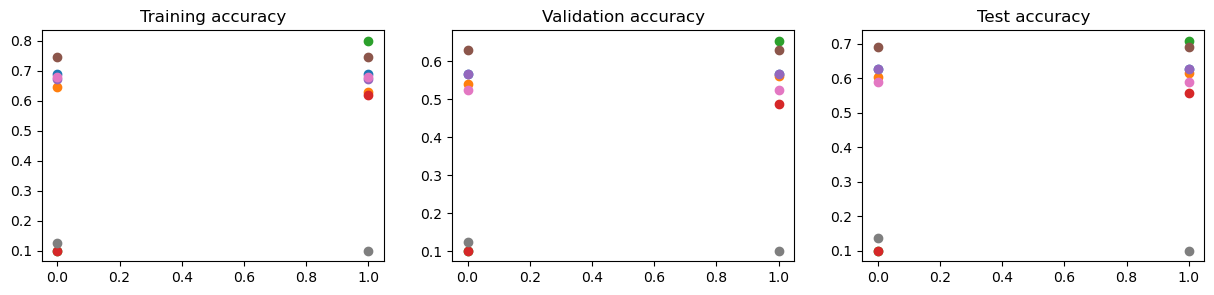

Crossing over remaining population:   0%|          | 0/4 [00:00<?, ?it/s]

Crossing over models 2 and 1
Block 0 deleted.


Training model:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch progress:   0%|          | 0/1407 [00:00<?, ?it/s]

Training model:   0%|          | 0/256 [00:00<?, ?it/s]

...

Calculating accuracy:   0%|          | 0/938 [00:00<?, ?it/s]

Calculating accuracy:   0%|          | 0/313 [00:00<?, ?it/s]

Calculating accuracy:   0%|          | 0/1407 [00:00<?, ?it/s]

Calculating accuracy:   0%|          | 0/938 [00:00<?, ?it/s]

Calculating accuracy:   0%|          | 0/313 [00:00<?, ?it/s]

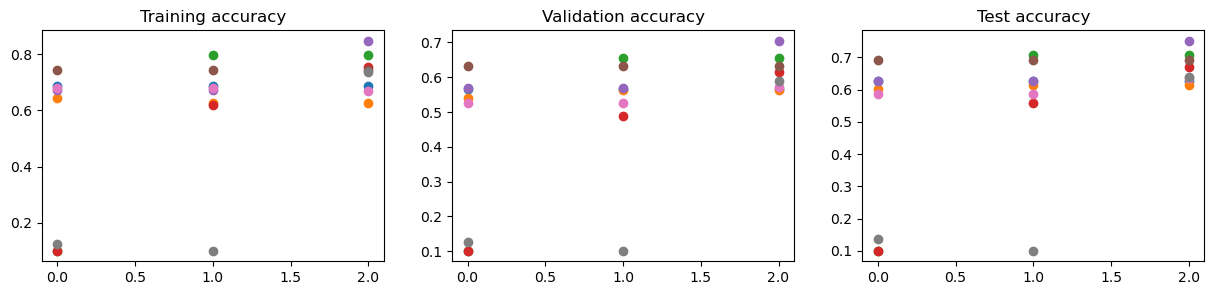

Crossing over remaining population:   0%|          | 0/4 [00:00<?, ?it/s]

Crossing over models 0 and 3
Added block between blocks 1 and 2.


Training model:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch progress:   0%|          | 0/1407 [00:00<?, ?it/s]

Training model:   0%|          | 0/256 [00:00<?, ?it/s]

...

Calculating accuracy:   0%|          | 0/938 [00:00<?, ?it/s]

Calculating accuracy:   0%|          | 0/313 [00:00<?, ?it/s]

Calculating accuracy:   0%|          | 0/1407 [00:00<?, ?it/s]

Calculating accuracy:   0%|          | 0/938 [00:00<?, ?it/s]

Calculating accuracy:   0%|          | 0/313 [00:00<?, ?it/s]

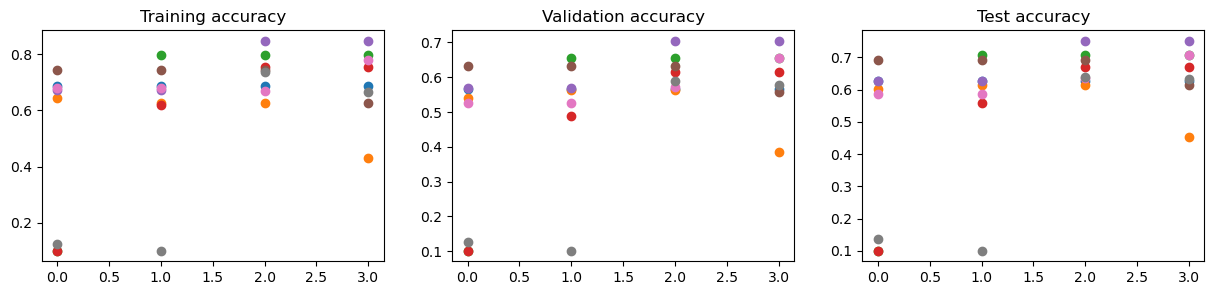

Crossing over remaining population:   0%|          | 0/4 [00:00<?, ?it/s]

Crossing over models 0 and 4
Skip connection added from block 0 to block 2.


Training model:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch progress:   0%|          | 0/1407 [00:00<?, ?it/s]

Training model:   0%|          | 0/256 [00:00<?, ?it/s]

...

Epoch progress:   0%|          | 0/1407 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch progress:   0%|          | 0/1407 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch progress:   0%|          | 0/1407 [00:00<?, ?it/s]

In [ ]:
# Genetic Algorithm - Each iteration we will only train as many models as we need to repopulate (in this case, half the population size) so we run for four times the number of iterations as in the ABC
method_args = {"iters" : 64,
               "ratio_keep" : 0.5,
               "selection_criterion" : "bin_tour",
               "crossover_weights" : "scores",
               "cross_point" : "weights",
               "mut_amount" : 1,
               "exhaustion_limit" : 16,
               "lr" : 1e-3,
               "patience" : 4}

chim.find_models(method = "genetic", method_args = method_args, verbose = True)
free_gpu_cache()

In [ ]:
init_population_path

Iteration:   0%|          | 0/16 [00:00<?, ?it/s]

Employed Bee phase:   0%|          | 0/8 [00:00<?, ?it/s]

Model weights reset.


Training model:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch progress:   0%|          | 0/1407 [00:00<?, ?it/s]

...

Calculating validation loss:   0%|          | 0/782 [00:00<?, ?it/s]

Calculating accuracy:   0%|          | 0/782 [00:00<?, ?it/s]

Calculating accuracy:   0%|          | 0/1407 [00:00<?, ?it/s]

Calculating accuracy:   0%|          | 0/313 [00:00<?, ?it/s]

Explorer Bee phase:   0%|          | 0/8 [00:00<?, ?it/s]

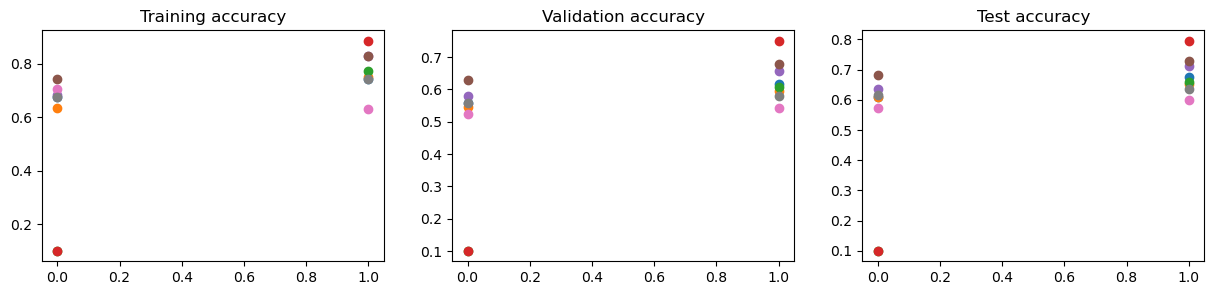

Employed Bee phase:   0%|          | 0/8 [00:00<?, ?it/s]

Added block between blocks 2 and 3.


Training model:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch progress:   0%|          | 0/1407 [00:00<?, ?it/s]

Training model:   0%|          | 0/256 [00:00<?, ?it/s]

...

Calculating validation loss:   0%|          | 0/782 [00:00<?, ?it/s]

Calculating accuracy:   0%|          | 0/782 [00:00<?, ?it/s]

Calculating accuracy:   0%|          | 0/1407 [00:00<?, ?it/s]

Calculating accuracy:   0%|          | 0/313 [00:00<?, ?it/s]

Explorer Bee phase:   0%|          | 0/8 [00:00<?, ?it/s]

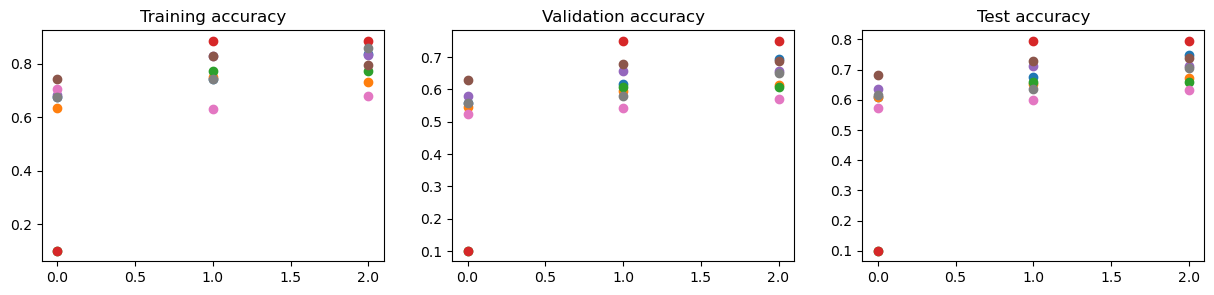

Employed Bee phase:   0%|          | 0/8 [00:00<?, ?it/s]

Classifier changed from simple to complex.


Training model:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch progress:   0%|          | 0/1407 [00:00<?, ?it/s]

Training model:   0%|          | 0/256 [00:00<?, ?it/s]

...

Epoch progress:   0%|          | 0/1407 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch progress:   0%|          | 0/1407 [00:00<?, ?it/s]

Calculating validation loss:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch progress:   0%|          | 0/1407 [00:00<?, ?it/s]

In [ ]:
# ABC - Each iteration we will train as many models as the population size on each of the two phases
method_args = {"iters" : 16,
               "exhaustion_limit" : 16,
               "lr" : 1e-3,
               "patience" : 4
               }
chim.find_models(method = "ABC", method_args = method_args, verbose = True)
free_gpu_cache()

In [ ]:
# PSO - Each iteration we will train as many models as the population size, so we train for double the number of iterations as in the ABC
method_args = {"iters" : 32,
               "cross_point" : "weights",
               "exhaustion_limit" : np.inf,
               "lr" : 1e-3,
               "patience" : 4
               }

chim3.find_models(method = "PSO", method_args = method_args, verbose = True)
free_gpu_cache()

We can use the Genetic Algorithm to search for promising regions in the solution space, and then use the ABC algorithm to exploit the best local architectures

In [ ]:
method_args = {"iters" : 32,
               "ratio_keep" : 0.5,
               "selection_criterion" : "bin_tour",
               "crossover_weights" : "scores",
               "cross_point" : "weights",
               "mut_amount" : 1,
               "exhaustion_limit" : 16,
               "lr" : 1e-3,
               "patience" : 4}

chim4.find_models(method = "genetic", method_args = method_args, verbose = True)

method_args = {"iters" : 8,
               "exhaustion_limit" : 16,
               "lr" : 1e-3,
               "patience" : 4
               }
chim4.find_models(method = "ABC", method_args = method_args, verbose = True)
free_gpu_cache()